<a href="https://colab.research.google.com/github/alfredoluis848/transfer-learning-cats-vs-dogs-dio/blob/main/transfer_learning_cats_dogs_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
!find "/content/drive/MyDrive" -iname "*kagglecatsanddogs*"

/content/drive/MyDrive/kagglecatsanddogs_5340.zip


In [4]:
!unzip -q "/content/drive/MyDrive/kagglecatsanddogs_5340.zip" -d "/content/dataset"

In [5]:
!ls /content/dataset

 CDLA-Permissive-2.0.pdf   PetImages  'readme[1].txt'


In [6]:
!ls /content/dataset/PetImages

Cat  Dog


In [7]:
pasta_gatos = "/content/dataset/PetImages/Cat"

arquivos_gatos = os.listdir(pasta_gatos)

print(len(arquivos_gatos))

12501


In [8]:
pasta_cachorros = "/content/dataset/PetImages/Dog"

arquivos_cachorros = os.listdir(pasta_cachorros)

print(len(arquivos_cachorros))

12501


In [9]:
from collections import Counter

extensoes = Counter(
    os.path.splitext(nome)[1].lower()
    for nome in arquivos_gatos
)

print(extensoes)

extensoes_dog = Counter(
    os.path.splitext(nome)[1].lower()
    for nome in arquivos_cachorros
)

print(extensoes_dog)

Counter({'.jpg': 12500, '.db': 1})
Counter({'.jpg': 12500, '.db': 1})


In [10]:
from PIL import Image
import os

pastas = [pasta_gatos, pasta_cachorros]

arquivos_corrompidos = []

for pasta in pastas:
    for nome in os.listdir(pasta):

        if nome.lower().endswith(".jpg"):

            caminho = os.path.join(pasta, nome)

            try:
                with Image.open(caminho) as img:
                    img.verify()

            except Exception:
                arquivos_corrompidos.append(caminho)

print("Arquivos corrompidos:", len(arquivos_corrompidos))

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Arquivos corrompidos: 2


In [13]:
gatos = [
    nome for nome in os.listdir(pasta_gatos)
    if nome.lower().endswith(".jpg")
]

cachorros = [
    nome for nome in os.listdir(pasta_cachorros)
    if nome.lower().endswith(".jpg")
]

print("Gatos:", len(gatos))
print("Cachorros:", len(cachorros))


Gatos: 12500
Cachorros: 12500


In [14]:
pasta_dataset = "/content/dataset/PetImages"
altura = 224
largura = 224
batch_size = 32


In [15]:
treino, validacao = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=(altura, largura),
    batch_size=batch_size,
    label_mode="binary"
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Using 5000 files for validation.


In [16]:
print(treino.class_names)

['Cat', 'Dog']


In [17]:
for imagens, labels in treino.take(1):
    print(imagens.shape)
    print(labels.shape)
    print(labels[:10])

(32, 224, 224, 3)
(32, 1)
tf.Tensor(
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]], shape=(10, 1), dtype=float32)


In [25]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(altura, largura, 3),
    include_top=False ,
    weights="imagenet"
)
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [21]:
quantidade_batches = tf.data.experimental.cardinality(validacao).numpy()

teste = validacao.take(quantidade_batches // 2)
validacao = validacao.skip(quantidade_batches // 2)

In [35]:
base_model.trainable = False
print("Variáveis treináveis:", len(base_model.trainable_variables))

Variáveis treináveis: 0


In [36]:
preprocessar = tf.keras.applications.mobilenet_v2.preprocess_input

In [37]:
entrada = tf.keras.Input(shape=(altura, largura, 3))

x = preprocessar(entrada)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

saida = tf.keras.layers.Dense(1, activation="sigmoid")(x)

modelo = tf.keras.Model(entrada, saida)

In [38]:
modelo.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [39]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

In [40]:
historico = modelo.fit(
    treino,
    validation_data=validacao,
    epochs=5
)

Epoch 1/5


KeyboardInterrupt: 

In [30]:
arquivos_invalidos = []

for pasta in [pasta_gatos, pasta_cachorros]:
    for nome in os.listdir(pasta):

        if nome.lower().endswith(".jpg"):
            caminho = os.path.join(pasta, nome)

            try:
                conteudo = tf.io.read_file(caminho)
                tf.io.decode_image(conteudo, channels=3)

            except Exception:
                arquivos_invalidos.append(caminho)

print("Arquivos inválidos:", len(arquivos_invalidos))

for arquivo in arquivos_invalidos[:20]:
    print(arquivo)

Arquivos inválidos: 9
/content/dataset/PetImages/Cat/4351.jpg
/content/dataset/PetImages/Cat/666.jpg
/content/dataset/PetImages/Cat/10404.jpg
/content/dataset/PetImages/Dog/2494.jpg
/content/dataset/PetImages/Dog/11912.jpg
/content/dataset/PetImages/Dog/11233.jpg
/content/dataset/PetImages/Dog/9500.jpg
/content/dataset/PetImages/Dog/11702.jpg
/content/dataset/PetImages/Dog/2317.jpg


In [31]:
for caminho in arquivos_invalidos:
    os.remove(caminho)

print("Removidos:", len(arquivos_invalidos))

Removidos: 9


In [32]:
treino, validacao = tf.keras.utils.image_dataset_from_directory(
    pasta_dataset,
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=(altura, largura),
    batch_size=batch_size,
    label_mode="binary"
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Using 4998 files for validation.


In [33]:
quantidade_batches = tf.data.experimental.cardinality(validacao).numpy()

teste = validacao.take(quantidade_batches // 2)
validacao = validacao.skip(quantidade_batches // 2)

In [41]:
entrada = tf.keras.Input(shape=(altura, largura, 3))

x = preprocessar(entrada)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

saida = tf.keras.layers.Dense(1, activation="sigmoid")(x)

modelo = tf.keras.Model(entrada, saida)

In [42]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

In [43]:
historico = modelo.fit(
    treino,
    validation_data=validacao,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 99ms/step - accuracy: 0.8866 - loss: 0.3141 - val_accuracy: 0.9301 - val_loss: 0.1711
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.9179 - loss: 0.2180 - val_accuracy: 0.9365 - val_loss: 0.1522
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9248 - loss: 0.1996 - val_accuracy: 0.9373 - val_loss: 0.1468
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.9260 - loss: 0.1904 - val_accuracy: 0.9329 - val_loss: 0.1589
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.9285 - loss: 0.1827 - val_accuracy: 0.9424 - val_loss: 0.1404


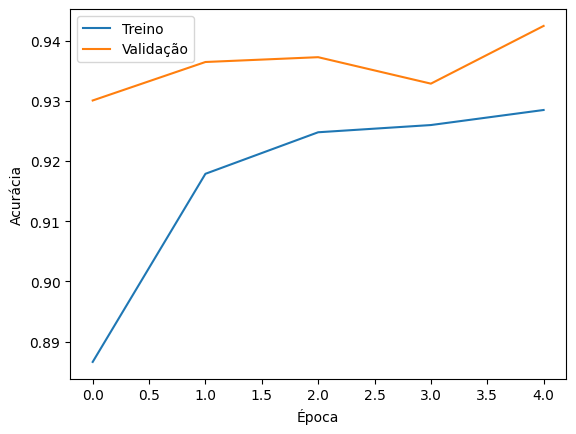

In [44]:
plt.plot(historico.history["accuracy"], label="Treino")
plt.plot(historico.history["val_accuracy"], label="Validação")

plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

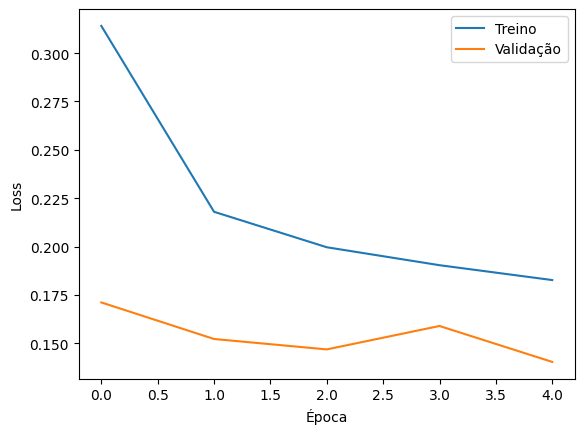

In [45]:
plt.plot(historico.history["loss"], label="Treino")
plt.plot(historico.history["val_loss"], label="Validação")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [46]:
loss_teste, accuracy_teste = modelo.evaluate(teste)

print("Loss no teste:", loss_teste)
print("Acurácia no teste:", accuracy_teste)

78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9487 - loss: 0.1377
Loss no teste: 0.13772320747375488
Acurácia no teste: 0.9487179517745972


In [47]:
for imagens, labels in teste.take(1):
    previsoes = modelo.predict(imagens)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


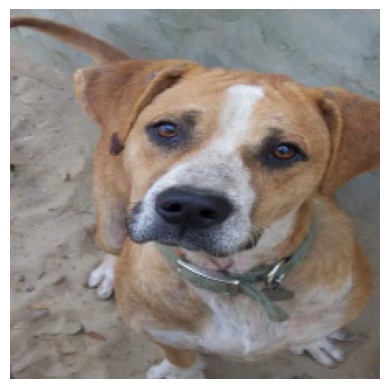

Valor previsto: 0.9998357
Classe real: 1.0


In [48]:
indice = 0

plt.imshow(imagens[indice].numpy().astype("uint8"))
plt.axis("off")
plt.show()

print("Valor previsto:", previsoes[indice][0])
print("Classe real:", labels[indice].numpy()[0])

In [49]:
modelo.save("/content/drive/MyDrive/modelo_cats_dogs.keras")